## __What factors are associated with high streaming songs on Spotify__

In [63]:
#I begin the analysis from importing the libraries I'll need, numpy and pandas for data manipulation, matplotlib and seaborn for visualizations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Objective
__The goal of this analysis is to identify factors associated with high Spotify streams.__

# Key Questions
- Do certain genres have higher average streams?
- Are newer songs more popular?
- Does explicit content influence popularity?
- Is popularity concentreted among a few artists?

In [64]:
#I load the data into a dataframe, setting the ranking to be an index, it's unique for every song, so new column for index is not needed. I set what will be treated as missing values
df = pd.read_csv('spotify_alltime_songs.csv', na_values=['?', 'NA', '', ' '], index_col='alltime_rank')
df.head(10) #to quickly check if the data is properly loaded

,song_title,artist,total_streams_billions,primary_genre,bpm,release_year,artist_country,explicit,danceability,energy,valence,acousticness,dataset_part
alltime_rank,,,,,,,,,,,,,
1,Blinding Lights,The Weeknd,5.26,Synth-Pop,171,2019,Canada,False,0.51,0.80,0.33,0.00,Spotify All-Time Most Streamed Top 100
2,Shape of You,Ed Sheeran,4.90,Pop/Dancehall,96,2017,UK,False,0.83,0.65,0.93,0.08,Spotify All-Time Most Streamed Top 100
3,Someone You Loved,Lewis Capaldi,4.05,Pop,77,2018,UK,False,0.60,0.45,0.42,0.29,Spotify All-Time Most Streamed Top 100
4,Sunflower,Post Malone & Swae Lee,3.98,Hip-Hop/Pop,93,2018,USA,False,0.76,0.49,0.84,0.15,Spotify All-Time Most Streamed Top 100
5,One Dance,Drake,3.92,Afrobeats/Pop,100,2016,Canada,False,0.79,0.62,0.68,0.09,Spotify All-Time Most Streamed Top 100
6,Stay,The Kid LAROI & Justin Bieber,3.87,Pop,170,2021,Australia,True,0.59,0.80,0.60,0.00,Spotify All-Time Most Streamed Top 100
7,Believer,Imagine Dragons,3.76,Alt Rock,125,2017,USA,False,0.33,0.86,0.45,0.07,Spotify All-Time Most Streamed Top 100
8,Rockstar,Post Malone ft. 21 Savage,3.72,Hip-Hop,159,2017,USA,True,0.55,0.52,0.13,0.08,Spotify All-Time Most Streamed Top 100
9,Dance Monkey,Tones and I,3.69,Pop,98,2019,Australia,False,0.83,0.63,0.73,0.14,Spotify All-Time Most Streamed Top 100


In [65]:
df.columns #I check what columns are in the df, not really necessary here since number of atributes is rather low, but its a good habit to have

Index(['song_title', 'artist', 'total_streams_billions', 'primary_genre',
       'bpm', 'release_year', 'artist_country', 'explicit', 'danceability',
       'energy', 'valence', 'acousticness', 'dataset_part'],
      dtype='str')

In [66]:
df.shape # I check the structure, if the number of rows is correct, 100 rows, 13 columns, everything is correct

(100, 13)

In [67]:
df.dtypes #check the column types

song_title                    str
artist                        str
total_streams_billions    float64
primary_genre                 str
bpm                         int64
release_year                int64
artist_country                str
explicit                     bool
danceability              float64
energy                    float64
valence                   float64
acousticness              float64
dataset_part                  str
dtype: object

In [68]:
df.describe() #quickly check the statistics as mean, min or max, to familiarize myself with value distribution of numeric variables

,total_streams_billions,bpm,release_year,danceability,energy,valence,acousticness
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,2.524600,115.780000,2016.800000,0.613500,0.636100,0.550600,0.153400
std,0.851432,30.540776,7.063922,0.142888,0.163824,0.238623,0.164637
min,1.400000,62.000000,1985.000000,0.300000,0.260000,0.070000,0.000000
25%,1.735000,95.000000,2016.000000,0.520000,0.527500,0.387500,0.020000
50%,2.435000,107.000000,2018.500000,0.620000,0.650000,0.565000,0.085000
75%,3.167500,139.000000,2021.000000,0.725000,0.775000,0.732500,0.245000
max,5.260000,191.000000,2024.000000,0.900000,0.960000,0.960000,0.760000


### Data cleaning


In [69]:
df.isna().sum()
#sums are 0, there are no missing values in any of the columns

song_title                0
artist                    0
total_streams_billions    0
primary_genre             0
bpm                       0
release_year              0
artist_country            0
explicit                  0
danceability              0
energy                    0
valence                   0
acousticness              0
dataset_part              0
dtype: int64

In [70]:
df.duplicated().sum() #no duplicated rows in the dataset

np.int64(0)

In [71]:
df = df.drop('dataset_part', axis=1) #the column has no value for the analysis, it indicates which dataset is being used, but since the analysis uses only one of the datasets the column is fully redundant and to be removed

In [72]:
df['primary_genre'].unique() #To simplify the analysis, genres will be grouped into broader categories (e.g., Pop, Hip-Hop, Rock), reducing noise from highly specific sub-genres.
df['genre'] = df['primary_genre'].str.split('/')
df = df.explode('genre')
df['genre'] = df['genre'].str.strip()
df = df.drop('primary_genre', axis=1) #removing the primary genre column

In [73]:
df['genre'].unique() #some genres have multiple sub-genres which creates a lot of clutter, to minimize it the broader categories for genres will be created
rap_keywords = ['rap', 'trap', 'drill']

df['genre'] = df['genre'].str.strip()

df['genre'] = df['genre'].apply(
    lambda x: 'Rap' if any(keyword.lower() in x.lower() for keyword in rap_keywords) else x
)
df['genre'] = df['genre'].apply(
    lambda x: 'Pop' if 'pop' in x.lower() else x
)
df['genre'] = df['genre'].apply(
    lambda x: 'Rock' if 'rock' in x.lower() else x
)
df['genre'] = df['genre'].apply(
    lambda x: 'Folk' if 'folk' in x.lower() else x
)
df['genre'].unique() 


<StringArray>
[      'Pop', 'Dancehall',   'Hip-Hop', 'Afrobeats',      'Rock',       'EDM',
      'Folk',  'Nu-Disco',       'Rap',   'Country',      'Funk',       'R&B',
 'Reggaeton',      'Soul',    'Grunge']
Length: 15, dtype: str

In [75]:
df.head(20)

,song_title,artist,total_streams_billions,bpm,release_year,artist_country,explicit,danceability,energy,valence,acousticness,genre
alltime_rank,,,,,,,,,,,,
1,Blinding Lights,The Weeknd,5.26,171,2019,Canada,False,0.51,0.80,0.33,0.00,Pop
2,Shape of You,Ed Sheeran,4.90,96,2017,UK,False,0.83,0.65,0.93,0.08,Pop
2,Shape of You,Ed Sheeran,4.90,96,2017,UK,False,0.83,0.65,0.93,0.08,Dancehall
3,Someone You Loved,Lewis Capaldi,4.05,77,2018,UK,False,0.60,0.45,0.42,0.29,Pop
4,Sunflower,Post Malone & Swae Lee,3.98,93,2018,USA,False,0.76,0.49,0.84,0.15,Hip-Hop
4,Sunflower,Post Malone & Swae Lee,3.98,93,2018,USA,False,0.76,0.49,0.84,0.15,Pop
5,One Dance,Drake,3.92,100,2016,Canada,False,0.79,0.62,0.68,0.09,Afrobeats
5,One Dance,Drake,3.92,100,2016,Canada,False,0.79,0.62,0.68,0.09,Pop
6,Stay,The Kid LAROI & Justin Bieber,3.87,170,2021,Australia,True,0.59,0.80,0.60,0.00,Pop


### Do certain genres have higher average streams?

C:\Users\kkarg\AppData\Local\Temp\ipykernel_18816\2720358939.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = by_genres.head(10), x='count', y='genre', palette='viridis')


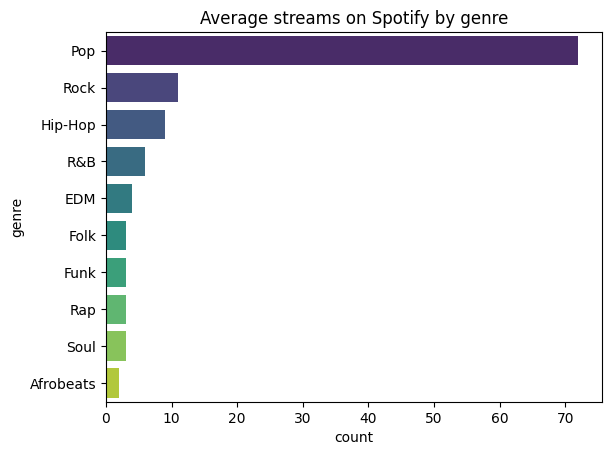

In [109]:
by_genres = df.groupby('genre').size().reset_index(name='count').sort_values(by='count', ascending=False)
sns.barplot(data = by_genres.head(10), x='count', y='genre', palette='viridis')
plt.title('Average streams on Spotify by genre')
plt.show()

In [110]:
by_genres

,genre,count
9,Pop,72
13,Rock,11
7,Hip-Hop,9
10,R&B,6
3,EDM,4
4,Folk,3
5,Funk,3
11,Rap,3
14,Soul,3
0,Afrobeats,2


The genre distribution is highly imbalanced, with Pop representing the vast majority of tracks (72 out of the total). Rock (11) and Hip-Hop (9) follow at much lower frequencies. In percentage terms, Pop constitutes the dominant share of the dataset, indicating a strong skew toward this genre, while other genres are relatively underrepresented.

### Are new songs more popular?

For the sake of consistancy the newer songs will be defined as songs that has released in the last 10 years, that is in years 2016-2026

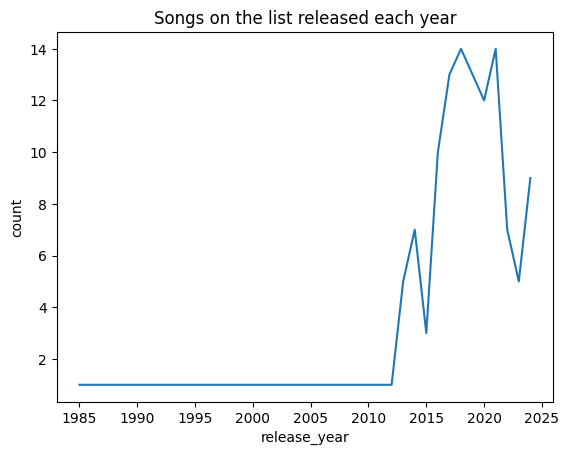

In [120]:
by_year = df.groupby('release_year').size().reset_index(name = 'count').sort_values(by = 'release_year', ascending=False)
sns.lineplot(data = by_year, x = 'release_year', y = 'count')
plt.title("Songs on the list released each year")
plt.show()

There is a visable spike in the number of songs released after year 2015, which indicates that the newer songs are much more likely to become popular on streaming platforms such as Spotify.

In [130]:
cutoff = 2016
before = df[df['release_year'] <= cutoff]['total_streams_billions'].sum()
after = df[df['release_year'] > cutoff]['total_streams_billions'].sum()

print(f"{(after/(before+after)* 100):.2f}% songs on the list have been released after 2016.")

73.29% songs on the list have been released after 2016.


In [141]:
print(f'{before:.2f} bln streams - songs before 2016,\n{after:.2f} bln streams - songs after 2016\n')
print(f'Songs released after 2016 have {(after/before):.2f} times more streams than songs released before')

83.06 bln streams - songs before 2016,
227.90 bln streams - songs after 2016

Songs released after 2016 have 2.74 times more streams than songs released before


More than 70% of all songs on the list have been released after 2016, and can be classified as newer songs. This shows that new songs are more likely to become all time hits, and on average more people are listening to them.

### Does explicit content influence popularity?

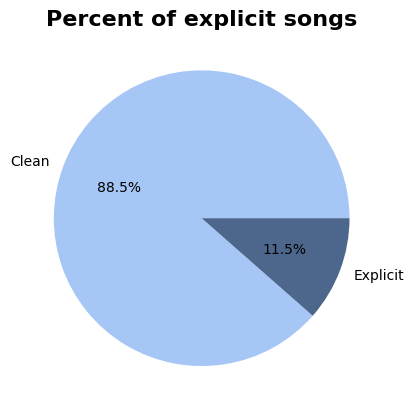

In [ ]:
counts = df['explicit'].value_counts()
counts.plot(kind='pie', labels=['Clean', 'Explicit'], autopct='%1.1f%%', colors=['#a6c6f5', '#4d668c'])
plt.ylabel('') 
plt.title('Percent of explicit songs', size=16, fontweight= 'bold')
plt.show()

In total 14 songs of 100 have explicit lyrics, that is slightly more than 11.5%. This indicates that a majority of popular songs on the list are not explicit, which in turn indicates that explicit lyrics are not likely to be a factor responsible for song's popularity. 

In [ ]:
explicit_songs = df[df['explicit']]
counts = explicit_songs['artist_country'].value_counts()
print(counts) # 11 out of 14 explicit songs have been released by an artist from USA, but it doesn't indicate that american songs are more explicit, to check that the overall number of songs from USA should be compared to the number of explicit ones

artist_country
USA          11
Canada        2
Australia     1
Name: count, dtype: int64


C:\Users\kkarg\AppData\Local\Temp\ipykernel_18816\3587663892.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=countries,


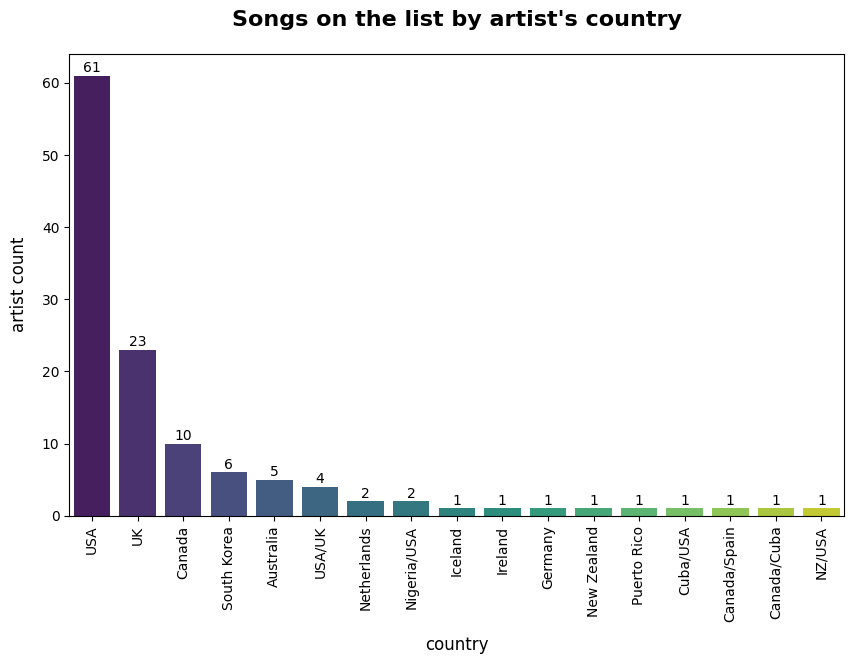

In [ ]:
#checking how many songs originate from US
countries = (df.groupby('artist_country')
             .size()
             .reset_index(name='count')
             .sort_values(by='count', ascending=False))
plt.figure(figsize=(10,6))
ax = sns.barplot(data=countries,
             x='artist_country',
             y='count',
            legend=False,
            palette='viridis')
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,  
        height + 0.5,                 
        int(height),                  
        ha='center'                  
    )
plt.title("Songs on the list by artist's country", size=16, pad=20, fontweight='bold', loc='center')
plt.xlabel('country', size=12, labelpad=10)
plt.ylabel('count', size=12, labelpad=10)
plt.xticks(rotation=90)
plt.show()

In [148]:
countries[countries['artist_country'].str.contains('US|United States', regex=True)]['count'].sum() 
print(f'{((13 / (countries[countries['artist_country'].str.contains('US|United States', regex=True)]['count'].sum())) * 100):.2f}% songs originating from the USA are explicit')

print(f"In comparison {((2 / (countries[countries['artist_country'] == 'Canada']['count'].iloc[0])) * 100):.0f}% songs from Canada have explicit lyrics")

18.84% songs originating from the USA are explicit
In comparison 20% songs from Canada have explicit lyrics


Despite majority of explicit songs being made by american artists, the songs originating from USA are not more explicit on average that those from other countries. Additionally major number of the most popular songs are made by american artists, which can indicate that songs originating from american music industry are likely to become worldwide hits, which can be explained by how developed the industry is in United States and how many of the most popular artists work under american labels.

### Is popularity concentreted among a few artists?